## Импорты, константы

In [ ]:
import os
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset, DataLoader
import random
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import math

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
RANDOM_STATE=42

## Загрузка датасета и первичный осмотр

In [5]:
root_dir = '/kaggle/input/brats-africa/BraTS-Africa'

In [6]:
class BraTSAfricaDataset(Dataset):
    def __init__(
        self,
        root_dir,
        subjects,
        mode="train",
        cache_in_ram=True,
        patch_size=(96, 96, 96),
        p_foreground=0.75,
        augment=False
    ):
        self.root_dir = root_dir
        self.subjects = subjects
        self.mode = mode
        self.patch_size = patch_size
        self.p_foreground = p_foreground
        self.augment = augment
        self.cache_in_ram = cache_in_ram if mode=="train" else False


        self.data = []       # (image, mask)
        self.fg_cache = []   # bbox per subject
        
        if self.cache_in_ram:
            print(f"[{mode}] Caching dataset in RAM...")
        
            for subj_path in self.subjects:
                image, mask, fg = self._load_subject(subj_path)
                self.data.append((image, mask))
                self.fg_cache.append(fg)

        print(f"[{mode}] Cached {len(self.data)} subjects ✅")

    # ---------------------------------------------------------
    # Загрузка одного пациента
    # ---------------------------------------------------------
    def _load_subject(self, subj_path):
    
        files = os.listdir(subj_path)
    
        def find_file(keyword):
            for f in files:
                if keyword in f and f.endswith((".nii", ".nii.gz")):
                    return os.path.join(subj_path, f)
            return None
    
        modality_names = ["t1n", "t1c", "t2w", "t2f"]
        modality_paths = {m: find_file(m) for m in modality_names}
        seg_path = find_file("seg")
    
        loaded = {}
        for m, p in modality_paths.items():
            if p is not None:
                img = nib.load(p)
                if not np.allclose(img.affine, np.diag(np.diag(img.affine))):
                    img = nib.as_closest_canonical(img)
                loaded[m] = np.asarray(img.dataobj, dtype=np.float32)
            
        ref = next(iter(loaded.values()))
        ref_shape = ref.shape
    
        channels = []
        for m in modality_names:
            if m in loaded:
                vol = loaded[m]
                if vol.shape != ref_shape:
                    vol = self._match_shape(vol, ref_shape)
                channels.append(vol)
            else:
                channels.append(np.zeros(ref_shape, dtype=np.float32))
    
        image = np.stack(channels, axis=0)  # [4, H, W, D]
        
        # ---------- MASK ----------
        seg_img = nib.load(seg_path)
        seg_img = nib.as_closest_canonical(seg_img)
        mask = np.asarray(seg_img.dataobj, dtype=np.int16)
    
        if mask.shape != ref_shape:
            mask = self._match_shape(mask, ref_shape)

        # ---------- TO TORCH CPU ----------
        image = torch.from_numpy(image).permute(0, 3, 1, 2).float().contiguous()
        mask  = torch.from_numpy(mask).permute(2, 0, 1).long().contiguous()

        # ----------Нормализация--------------
        image = self.normalize_brain(image)
        
        # ---------- FG BBOX CACHE ----------
        def get_bbox(label):
            vox = torch.nonzero(mask == label, as_tuple=False)
            if len(vox) == 0:
                return None
            mins = vox.min(0).values.cpu().numpy()
            maxs = vox.max(0).values.cpu().numpy()

            return (mins.tolist(), maxs.tolist())
    
        fg_cache = {
            3: get_bbox(3),
            1: get_bbox(1),
            2: get_bbox(2),
        }
    
        return image, mask, fg_cache

    #----Нормализация__________________________________________
    def normalize_brain(self, image):
        # image: torch [C,D,H,W]
    
        for c in range(image.shape[0]):
            channel = image[c]
    
            mask = channel != 0
            if mask.sum() == 0:
                continue
    
            vox = channel[mask]
    
            mean = vox.mean()
            std = vox.std()
    
            std = torch.clamp(std, min=1e-6)
    
            channel[mask] = (vox - mean) / std
            channel[~mask] = 0
    
        return image

    # ---------------------------------------------------------
    def _match_shape(self, vol, target_shape):
        Ht, Wt, Dt = target_shape
        H, W, D = vol.shape

        vol = vol[
            max(0,(H-Ht)//2):max(0,(H-Ht)//2)+min(Ht,H),
            max(0,(W-Wt)//2):max(0,(W-Wt)//2)+min(Wt,W),
            max(0,(D-Dt)//2):max(0,(D-Dt)//2)+min(Dt,D)
        ]

        pad_h = Ht - vol.shape[0]
        pad_w = Wt - vol.shape[1]
        pad_d = Dt - vol.shape[2]

        vol = np.pad(vol, (
            (pad_h//2, pad_h - pad_h//2),
            (pad_w//2, pad_w - pad_w//2),
            (pad_d//2, pad_d - pad_d//2)
        ), mode="constant")

        return vol

    # ---------------------------------------------------------
    # Длина датасета
    # ---------------------------------------------------------
    def __len__(self):
        return len(self.subjects)

    # ---------------------------------------------------------
    def __getitem__(self, idx):

        if self.cache_in_ram:
            image, mask = self.data[idx]
            fg_cache = self.fg_cache[idx]
        else:
            image, mask, fg_cache = self._load_subject(self.subjects[idx])
    
        if self.mode == "train":
            image, mask = self._get_patch(image, mask, fg_cache)
    
        if self.mode == "train" and self.augment:
            image, mask = self._augment_3d(image, mask)
    
        return image.contiguous(), mask.contiguous()

    # ---------------------------------------------------------
    def _get_patch(self, image, mask, fg_cache):
        _, D, H, W = image.shape
        pd, ph, pw = self.patch_size

        # ---------- выбираем центр ----------
        if random.random() < self.p_foreground:
            for label in (3, 1, 2):
                bbox = fg_cache[label]
                if bbox is not None:
                    mins, maxs = bbox
                    cd = random.randint(mins[0], maxs[0])
                    ch = random.randint(mins[1], maxs[1])
                    cw = random.randint(mins[2], maxs[2])
                    break
            else:
                cd = random.randint(0, D - 1)
                ch = random.randint(0, H - 1)
                cw = random.randint(0, W - 1)
        else:
            cd = random.randint(0, D - 1)
            ch = random.randint(0, H - 1)
            cw = random.randint(0, W - 1)
    
        # ---------- вычисляем окно ----------
        d0 = cd - pd // 2
        h0 = ch - ph // 2
        w0 = cw - pw // 2
    
        # ---------- сдвигаем окно внутрь объёма ----------
        d0 = max(0, min(d0, D - pd))
        h0 = max(0, min(h0, H - ph))
        w0 = max(0, min(w0, W - pw))
        
    
        d1 = d0 + pd
        h1 = h0 + ph
        w1 = w0 + pw
    
        image_patch = image[:, d0:d1, h0:h1, w0:w1]
        mask_patch  = mask[d0:d1, h0:h1, w0:w1]
    
        return image_patch, mask_patch

    # ---------------------------------------------------------
    def _augment_3d(self, image, mask):
        if torch.rand(1) < 0.5:
            image = torch.flip(image, dims=[2])
            mask  = torch.flip(mask, dims=[1])

        if torch.rand(1) < 0.5:
            image = torch.flip(image, dims=[3])
            mask  = torch.flip(mask, dims=[2])

        if torch.rand(1) < 0.5:
            k = random.randint(0, 3)
            image = torch.rot90(image, k, dims=(2,3))
            mask  = torch.rot90(mask, k, dims=(1,2))

        return image, mask

In [7]:
def collect_subject_paths(root_dir):
    subjects = []

    for group in os.listdir(root_dir):
        group_path = os.path.join(root_dir, group)
        if not os.path.isdir(group_path):
            continue

        for subj in os.listdir(group_path):
            subj_path = os.path.join(group_path, subj)
            if os.path.isdir(subj_path):
                subjects.append(subj_path)

    print(f"Total subjects found: {len(subjects)}")
    return subjects

In [8]:
all_subjects = collect_subject_paths(root_dir)
print("Пример пациента:", all_subjects[10])

Total subjects found: 146
Пример пациента: /kaggle/input/brats-africa/BraTS-Africa/95_Glioma/BraTS-SSA-00163-000


In [9]:
def load_subject_raw(subj_path):
    files = os.listdir(subj_path)

    def find_file(keyword):
        for f in files:
            if keyword in f and f.endswith((".nii", ".nii.gz")):
                return os.path.join(subj_path, f)
        return None

    modality_names = ["t1n", "t1c", "t2w", "t2f"]

    images = {}
    for m in modality_names:
        path = find_file(m)
        if path:
            images[m] = nib.load(path).get_fdata()

    seg_path = find_file("seg")
    mask = nib.load(seg_path).get_fdata()

    return images, mask

In [10]:
subj_path = all_subjects[10]

images_raw, mask_raw = load_subject_raw(subj_path)

for k in images_raw:
    print(f'{k}:', images_raw[k].shape)

print("Mask:", mask_raw.shape)

t1n: (240, 240, 155)
t1c: (240, 240, 155)
t2w: (240, 240, 155)
t2f: (240, 240, 155)
Mask: (240, 240, 155)


In [11]:
train_subjects, val_subjects = train_test_split(
    all_subjects,
    test_size=0.25,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [12]:
train_dataset = BraTSAfricaDataset(
    root_dir,
    subjects=train_subjects,
    mode="train",
    augment=True
)

val_dataset = BraTSAfricaDataset(
    root_dir,
    subjects=val_subjects,
    mode="val",
    augment=False
)

[train] Caching dataset in RAM...
[train] Cached 109 subjects ✅
[val] Cached 0 subjects ✅


In [13]:
image_tr, mask_tr = train_dataset[10]
print("Image shape:", image_tr.shape)
print("Mask shape:", mask_tr.shape)
print("Unique labels in mask:", torch.unique(mask_tr))

Image shape: torch.Size([4, 96, 96, 96])
Mask shape: torch.Size([96, 96, 96])
Unique labels in mask: tensor([0, 1, 2, 3])


In [14]:
image_val, mask_val = val_dataset[10]
print("Image shape:", image_val.shape)
print("Mask shape:", mask_val.shape)
print("Unique labels in mask:", torch.unique(mask_val))

Image shape: torch.Size([4, 155, 240, 240])
Mask shape: torch.Size([155, 240, 240])
Unique labels in mask: tensor([0, 1, 2, 3])


In [15]:
def show_slice(dataset, patient_idx=None, slice_idx=None, n_random=3, figsize_per_row=5):
    
    titles = ["T1n", "T1c", "T2w", "T2f", "Segmentation"]

    if patient_idx is None:
        patient_idx = random.sample(range(len(dataset)), n_random)

    n_patients = len(patient_idx)
    n_cols = 5

    fig, axes = plt.subplots(
        n_patients, n_cols,
        figsize=(figsize_per_row*n_cols, figsize_per_row*n_patients)
    )

    if n_patients == 1:
        axes = [axes]

    for row, patient_idx in enumerate(patient_idx):
        image, mask = dataset[patient_idx]

        # выбираем срез
        if slice_idx is None:
            current_slice = torch.argmax(mask.sum(dim=(1,2)))
        elif isinstance(slice_idx, int):
            current_slice = slice_idx
        else:
            current_slice = slice_idx[row]

        image = image.cpu()
        mask = mask.cpu()

        for col in range(4):
            axes[row][col].imshow(image[col, current_slice], cmap="gray")
            axes[row][col].axis("off")

            if row == 0:
                axes[row][col].set_title(titles[col], fontsize=20)

        # маска
        axes[row][4].imshow(image[0, current_slice], cmap="gray")
        axes[row][4].imshow(mask[current_slice], cmap="jet", alpha=0.8)
        axes[row][4].axis("off")

        if row == 0:
            axes[row][4].set_title(titles[4], fontsize=20)
            
    plt.tight_layout()
    plt.show()

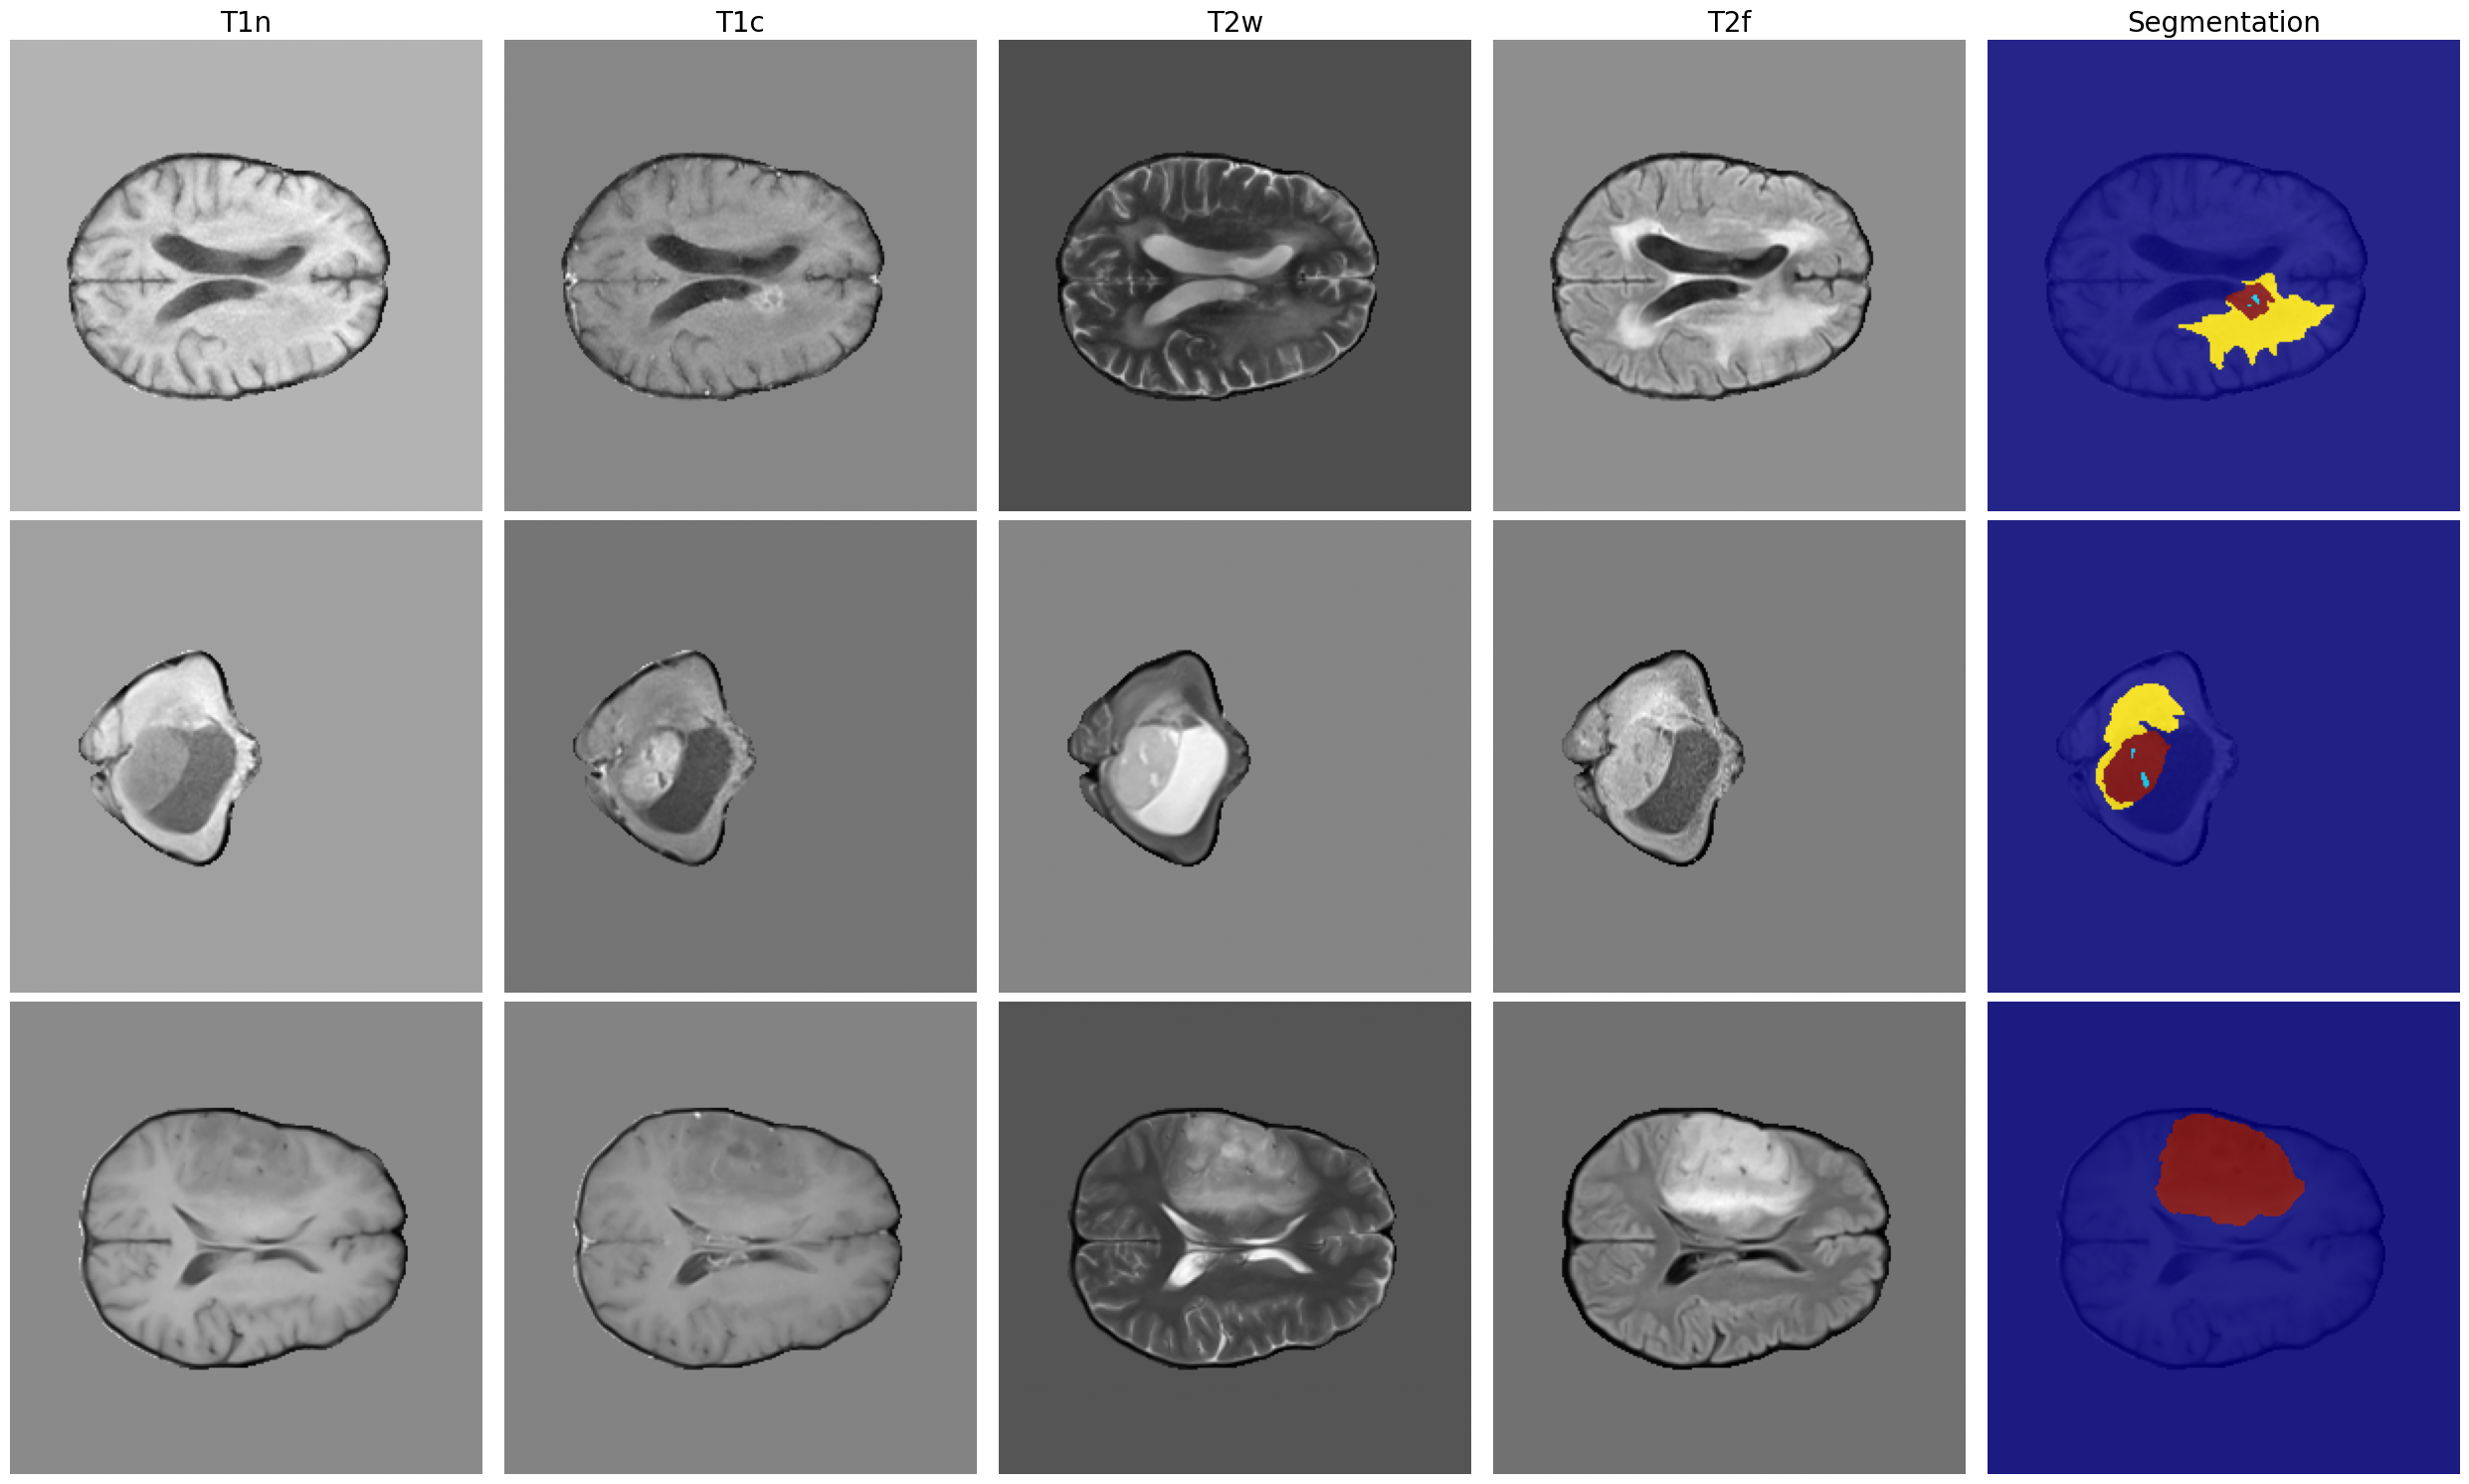

In [16]:
show_slice(dataset=val_dataset, patient_idx=[0, 1, 2],
           figsize_per_row=5)

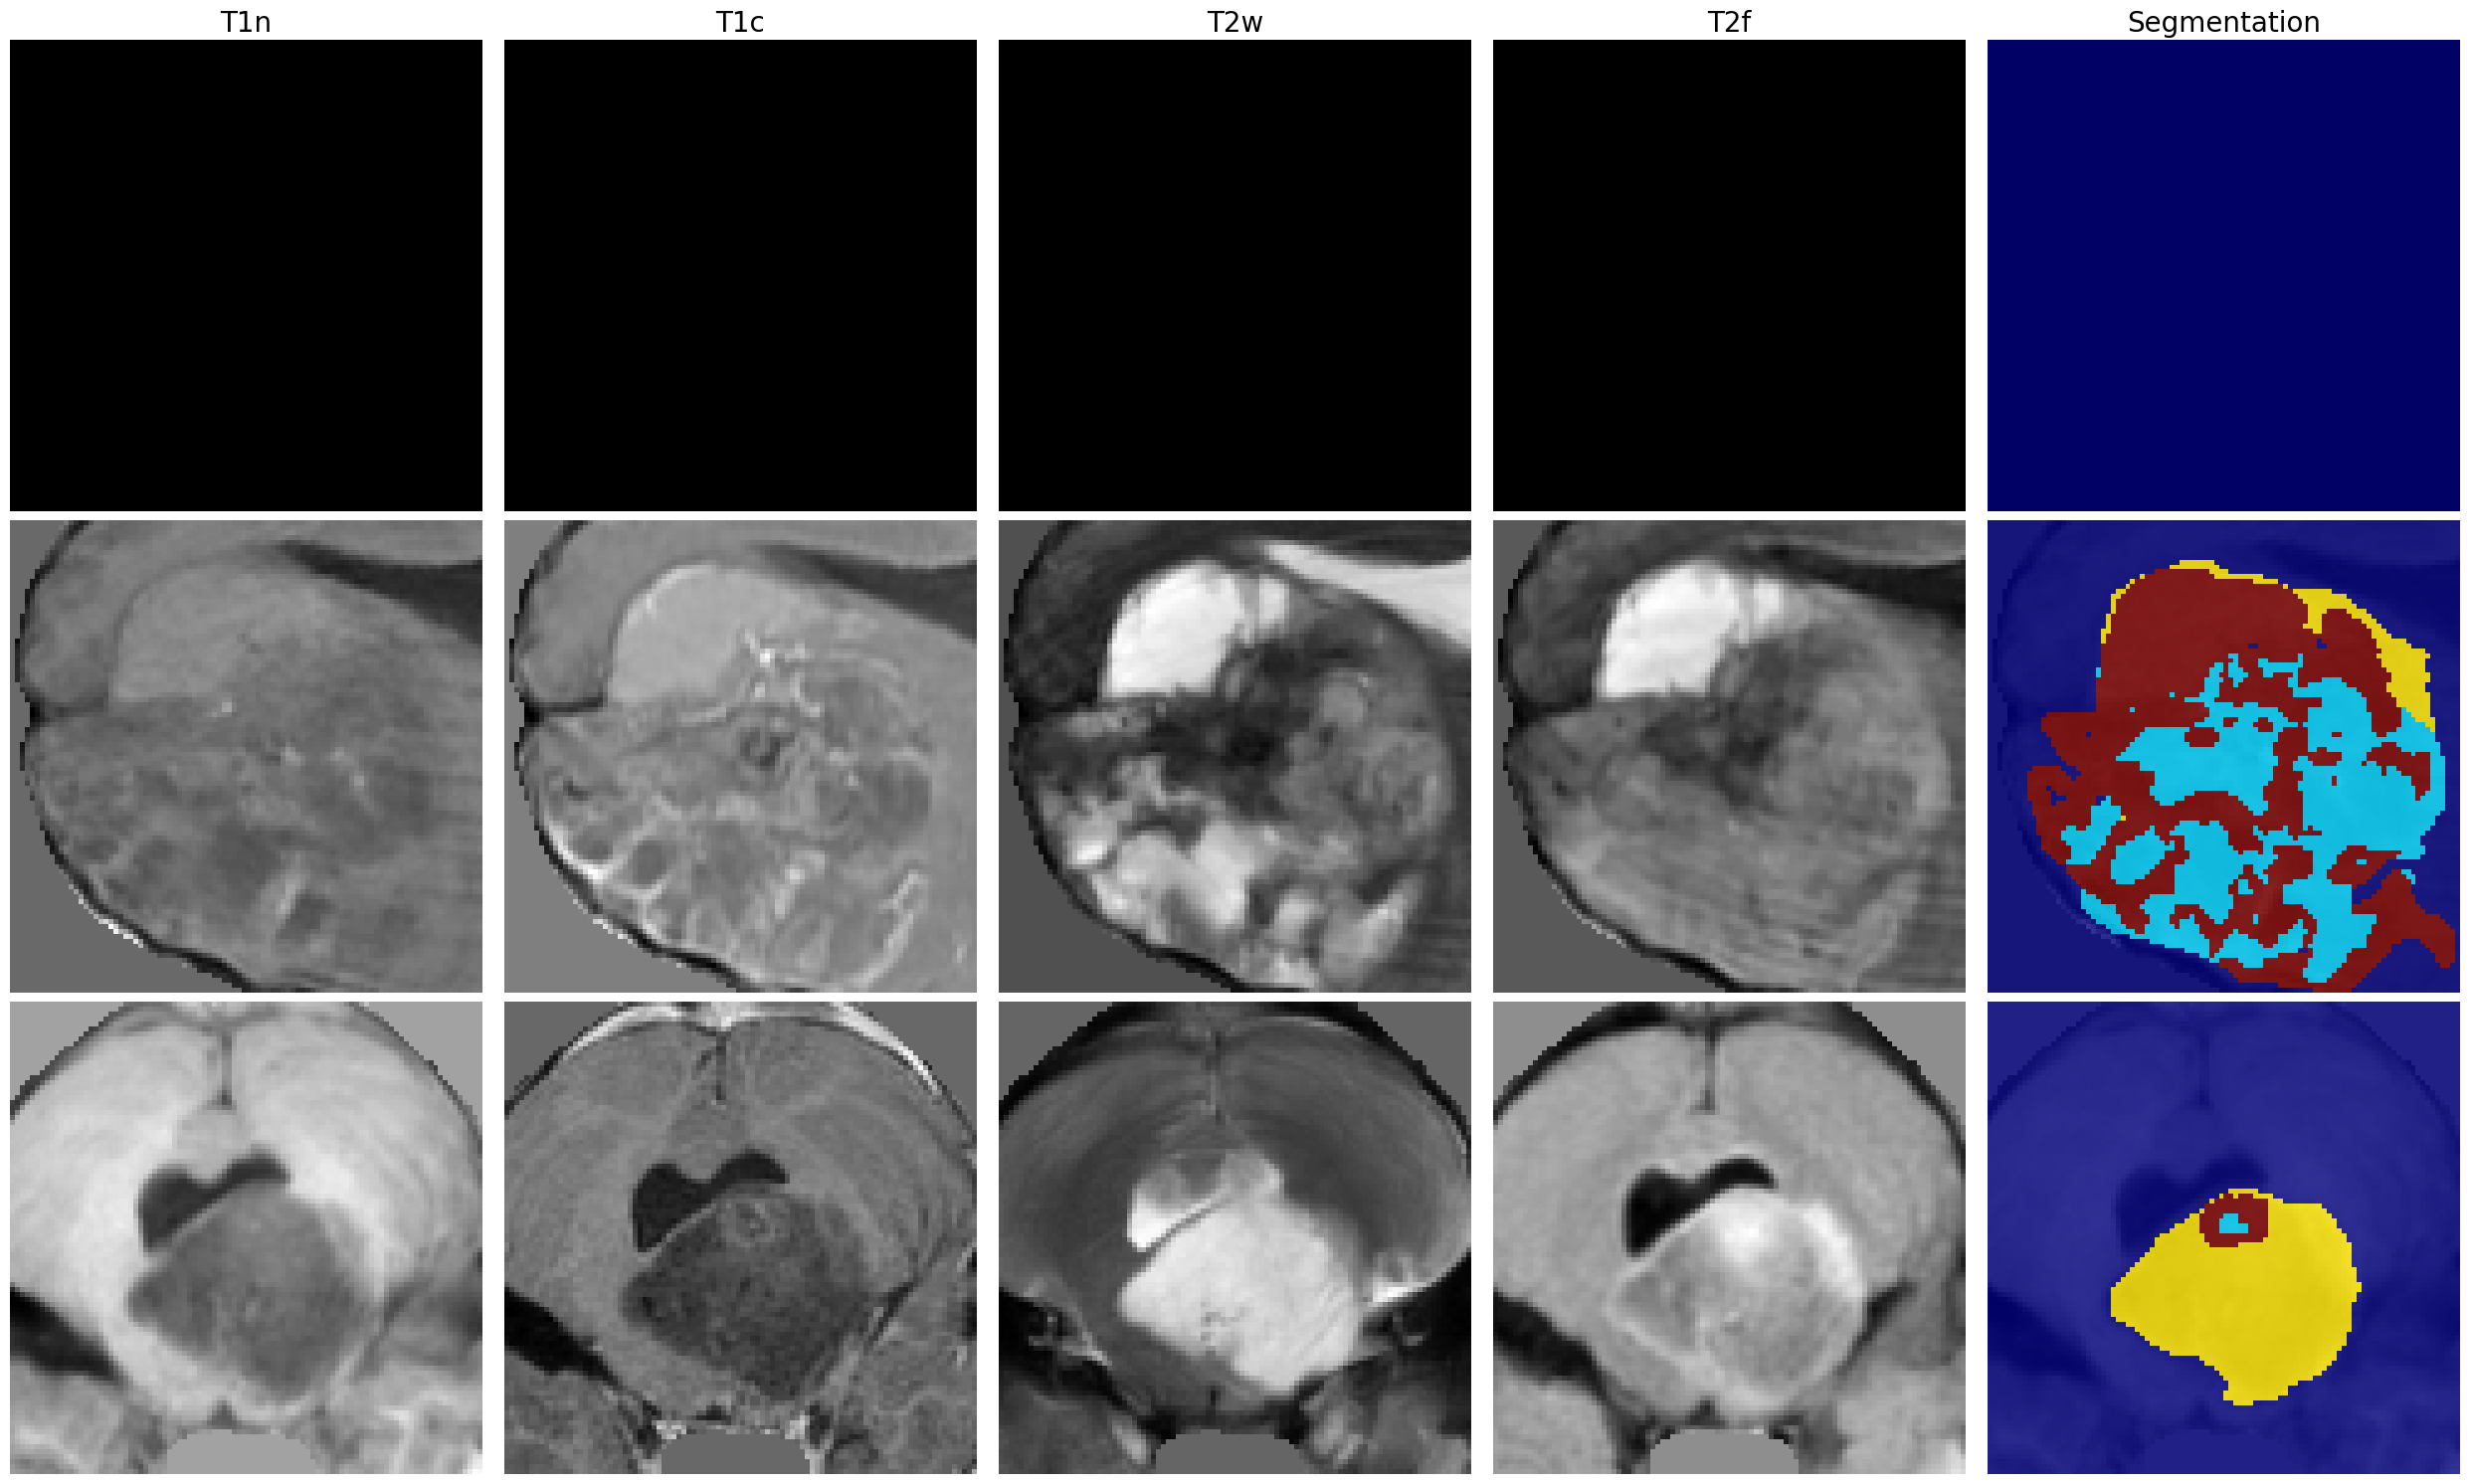

In [17]:
show_slice(dataset=train_dataset, patient_idx=[15, 35, 60],
           figsize_per_row=5)

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
    )
    
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
    )

## Сегментация с помощью ResidualUNet3D

In [19]:
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [20]:
class FastResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, norm=True):
        super().__init__()

        self.conv1 = nn.Conv3d(in_ch, out_ch, (1,3,3), padding=(0,1,1), bias=False)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False)

        self.bn1 = nn.BatchNorm3d(out_ch) if norm else nn.Identity()
        self.bn2 = nn.BatchNorm3d(out_ch) if norm else nn.Identity()

        self.relu = nn.ReLU(inplace=True)

        self.skip = nn.Conv3d(in_ch, out_ch, 1, bias=False) if in_ch!=out_ch else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        out = self.relu(x + identity)
        return out

In [21]:
class FastDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=(1,2,2), mode='trilinear', align_corners=False),
            nn.Conv3d(in_ch, out_ch, 1, bias=False)
        )

        self.conv = FastResidualBlock(out_ch + skip_ch, out_ch, norm=False)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [22]:
class FastBottleneck(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv3d(ch, ch, 3, padding=1, dilation=1)
        self.conv2 = nn.Conv3d(ch, ch, 3, padding=2, dilation=2)
        self.conv3 = nn.Conv3d(ch, ch, 3, padding=4, dilation=4)
        self.fuse  = nn.Conv3d(ch*3, ch, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        c1 = self.conv1(x)
        c2 = self.conv2(x)
        c3 = self.conv3(x)
        return x + self.fuse(self.relu(torch.cat([c1,c2,c3],1)))

In [23]:
class FastResidualUNet3D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4, base_c=32):
        super().__init__()
        self.out_channels = num_classes 

        self.enc1 = FastResidualBlock(in_channels, base_c)
        self.enc2 = FastResidualBlock(base_c, base_c*2)
        self.enc3 = FastResidualBlock(base_c*2, base_c*4)
        self.enc4 = FastResidualBlock(base_c*4, base_c*8)

        self.pool = nn.MaxPool3d((1,2,2))

        self.bottleneck = nn.Sequential(
        FastResidualBlock(base_c*8, base_c*12),
        FastResidualBlock(base_c*12, base_c*12),
        FastBottleneck(base_c*12),
        nn.Dropout3d(0.15)
        )


        self.dec4 = FastDecoderBlock(base_c*12, base_c*8, base_c*6)
        self.dec3 = FastDecoderBlock(base_c*6, base_c*4, base_c*4)
        self.dec2 = FastDecoderBlock(base_c*4, base_c*2, base_c*2)
        self.dec1 = FastDecoderBlock(base_c*2, base_c, base_c)

        self.out_conv = nn.Conv3d(base_c, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(b, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)

        out = self.out_conv(d1)
        
        return out

In [24]:
@torch.no_grad()
def dice_score_wt_tc_et(logits, targets, eps=1e-6):
    """
    logits:  [B, C, D, H, W]
    targets: [B, D, H, W]
    return: dict {WT, TC, ET}
    """
    preds = torch.argmax(logits, dim=1)

    # --- регионы ---
    wt_pred = (preds > 0)
    wt_gt   = (targets > 0)

    tc_pred = (preds == 1) | (preds == 3)
    tc_gt   = (targets == 1) | (targets == 3)

    et_pred = (preds == 3)
    et_gt   = (targets == 3)

    def dice(p, g):
        inter = (p & g).sum().float()
        union = p.sum() + g.sum()
        if union == 0:
            return torch.tensor(1.0, device=logits.device)
        return (2 * inter + eps) / (union + eps)

    return {
        "WT": dice(wt_pred, wt_gt).item(),
        "TC": dice(tc_pred, tc_gt).item(),
        "ET": dice(et_pred, et_gt).item()
    }

In [25]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

In [26]:
def extract_boundary(mask):
    """
    mask: [B,1,D,H,W] бинарная
    return: boundary map
    """
    dilated = F.max_pool3d(mask.float(), 3, stride=1, padding=1)
    eroded  = -F.max_pool3d(-mask.float(), 3, stride=1, padding=1)
    boundary = (dilated - eroded) > 0
    return boundary.float()

In [27]:
class FastBoundaryLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits, target):
        probs = torch.softmax(logits, dim=1)

        # берём опухоль целиком (WT)
        tumor_prob = probs[:,1] + probs[:,2] + probs[:,3]
        tumor_prob = tumor_prob.unsqueeze(1)

        tumor_gt = (target > 0).unsqueeze(1).float()

        boundary_gt = extract_boundary(tumor_gt)

        loss = ((1 - tumor_prob) * boundary_gt).mean()

        return loss

In [28]:
class RegionDiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def dice(self, p, g):
        inter = (p * g).sum(dim=(2,3,4))
        union = p.sum(dim=(2,3,4)) + g.sum(dim=(2,3,4))
        return (2*inter + self.eps) / (union + self.eps)

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)

        # one-hot
        targets_oh = F.one_hot(targets, 4).permute(0,4,1,2,3).float()

        # --- регионы ---
        wt_p = probs[:,1:].sum(1, keepdim=True)
        wt_g = targets_oh[:,1:].sum(1, keepdim=True)

        tc_p = probs[:,[1,3]].sum(1, keepdim=True)
        tc_g = targets_oh[:,[1,3]].sum(1, keepdim=True)

        et_p = probs[:,3:4]
        et_g = targets_oh[:,3:4]

        dice_wt = self.dice(wt_p, wt_g)
        dice_tc = self.dice(tc_p, tc_g)
        dice_et = self.dice(et_p, et_g)

        loss = 1 - (dice_wt + 1.5*dice_tc + 1.5*dice_et) / 4
        return loss.mean()

In [29]:
def set_epoch(self, epoch):
    self.epoch = epoch

In [30]:
class TCFocusedLoss(nn.Module):
    def __init__(self, max_epochs):
        super().__init__()
        self.focal = FocalLoss(gamma=1.5)
        self.region = RegionDiceLoss()
        self.boundary = FastBoundaryLoss()
        self.max_epochs = max_epochs
        self.epoch = 0
        self.eps = 1e-6

    def set_epoch(self, epoch):
        self.epoch = epoch

    def get_boundary_weight(self):
        progress = self.epoch / self.max_epochs
        if self.epoch <= 10:
            loss = 0
        else:
            loss = 0.4 * (1 - math.cos(math.pi * progress)) / 2
        return loss

    def dice_class1(self, probs, target):
        p = probs[:,1]
        g = (target==1).float()
        inter = (p*g).sum()
        union = p.sum() + g.sum()
        return 1 - (2*inter + self.eps)/(union + self.eps)

    def dice_et(self, probs, target):
        p = probs[:,3]
        g = (target==3).float()
        inter = (p*g).sum()
        union = p.sum() + g.sum()
        return 1 - (2*inter + self.eps)/(union + self.eps)

    def forward(self, logits, target):
        probs = torch.softmax(logits,1)

        loss_focal = self.focal(logits,target)
        loss_region = self.region(logits,target)
        loss_boundary = self.boundary(logits,target)
        loss_tc = self.dice_class1(probs, target)
        loss_et = self.dice_et(probs, target)

        w_b = self.get_boundary_weight()

        return (
            0.25*loss_focal +
            0.45*loss_region +
            0.25*loss_et+
            0.15*loss_tc+
            w_b * loss_boundary
        )

In [31]:
gaussian_cache = {}

def get_gaussian_weight(patch_size, device):
    key = (patch_size, device)
    if key in gaussian_cache:
        return gaussian_cache[key]

    dz, dy, dx = patch_size
    z = torch.linspace(-1, 1, dz, device=device)
    y = torch.linspace(-1, 1, dy, device=device)
    x = torch.linspace(-1, 1, dx, device=device)

    zz, yy, xx = torch.meshgrid(z, y, x, indexing='ij')
    g = torch.exp(-(xx**2 + yy**2 + zz**2) / 0.5)
    g = g / g.max()
    g = g.half().unsqueeze(0).unsqueeze(0)  # [1,1,D,H,W]

    gaussian_cache[key] = g
    return g

In [32]:
@torch.no_grad()
def sliding_window_fast(model, image, patch_size, stride, sw_batch_size=4):
    """
    Ускоренная sliding-window inference.
    Без вложенных циклов.
    """

    B, C, D, H, W = image.shape
    pd, ph, pw = patch_size
    sd, sh, sw = stride
    device = image.device

    # координаты начала окон
    ds = list(range(0, D - pd + 1, sd))
    hs = list(range(0, H - ph + 1, sh))
    ws = list(range(0, W - pw + 1, sw))

    if ds[-1] != D - pd: ds.append(D - pd)
    if hs[-1] != H - ph: hs.append(H - ph)
    if ws[-1] != W - pw: ws.append(W - pw)

    coords = [(d, h, w) for d in ds for h in hs for w in ws]

    num_classes = model.out_channels

    output = torch.zeros((B, num_classes, D, H, W),
                         device=device, dtype=torch.float32)
    norm_map = torch.zeros((1, 1, D, H, W),
                           device=device, dtype=torch.float32)

    weight = get_gaussian_weight(patch_size, device).float()

    # === батчевый прогон ===
    for i in range(0, len(coords), sw_batch_size):

        batch_coords = coords[i:i+sw_batch_size]

        patches = torch.cat([
            image[..., d:d+pd, h:h+ph, w:w+pw]
            for (d, h, w) in batch_coords
        ], dim=0)

        with torch.amp.autocast("cuda"):
            preds = model(patches)

        preds = preds.float()

        for j, (d, h, w) in enumerate(batch_coords):
            output[..., d:d+pd, h:h+ph, w:w+pw] += preds[j:j+1] * weight
            norm_map[..., d:d+pd, h:h+ph, w:w+pw] += weight

    return output / norm_map.clamp_min(1e-6)

In [33]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0
    dice_scores = {'WT':0, 'TC':0, 'ET':0}

    for images, masks in loader:
        images = images.contiguous().to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 12)
        
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        # DICE scores
        scores = dice_score_wt_tc_et(outputs, masks)
        for k in dice_scores:
            dice_scores[k] += scores[k]

    mean_loss = total_loss / len(loader)
    mean_dice = {k: dice_scores[k]/len(loader) for k in dice_scores}

    return mean_loss, mean_dice

In [34]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, patch_size=(128,128,128),
                       stride=(96,96,96)):

    model.eval()
    total_loss = 0
    dice_scores = {'WT':0, 'TC':0, 'ET':0}

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        logits = sliding_window_fast(model, images, patch_size, stride, sw_batch_size=4)

        loss = criterion(logits, masks)

        total_loss += loss.item()

        scores = dice_score_wt_tc_et(logits, masks)

        for k in dice_scores:
            dice_scores[k] += scores[k]

    mean_loss = total_loss / len(loader)
    mean_dice = {k: dice_scores[k]/len(loader) for k in dice_scores}
    return mean_loss, mean_dice

In [35]:
epochs = 40

model = FastResidualUNet3D(in_channels=4, num_classes=4, base_c=32).to(device)
scaler = torch.amp.GradScaler("cuda")
criterion = TCFocusedLoss(max_epochs=epochs).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4, fused=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=5e-6)

/usr/local/lib/python3.12/dist-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [37]:
stride = (96,96,96)
best_val = 0.0
epochs_no_improve = 0
patience = 10

for epoch in range(epochs):

    criterion.set_epoch(epoch)

    train_loss, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion,
        scaler
    )

    torch.cuda.empty_cache()

    # --- validation ---
    val_loss, val_dice = validate_one_epoch(
        model,
        val_loader,
        criterion,
        stride=stride
    )

    mean_val_dice = (val_dice['WT'] +
        val_dice['TC'] +
        1.5 * val_dice['ET']
    ) / 3.5
      

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}")

    print(f"  Train Dice: WT={train_dice['WT']:.4f},TC={train_dice['TC']:.4f},ET={train_dice['ET']:.4f}")
    print(f"  Val   Dice: WT={val_dice['WT']:.4f},TC={val_dice['TC']:.4f},ET={val_dice['ET']:.4f}")
    print(f"  Mean val Dice: {mean_val_dice:.4f}")

    # --- Early stopping и сохранение ---
    if mean_val_dice > best_val:
        best_val = mean_val_dice
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Saved new best model")

    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break
    print("-"*50)

Epoch [1/40]
  Train Loss: 0.6429
  Val   Loss: 0.4788
  Train Dice: WT=0.5020,TC=0.4519,ET=0.4202
  Val   Dice: WT=0.7129,TC=0.5618,ET=0.5760
  Mean val Dice: 0.6111
✅ Saved new best model
--------------------------------------------------
Epoch [2/40]
  Train Loss: 0.4962
  Val   Loss: 0.3742
  Train Dice: WT=0.6483,TC=0.5499,ET=0.5746
  Val   Dice: WT=0.7187,TC=0.6368,ET=0.6808
  Mean val Dice: 0.6790
✅ Saved new best model
--------------------------------------------------
Epoch [3/40]
  Train Loss: 0.4601
  Val   Loss: 0.3595
  Train Dice: WT=0.6805,TC=0.5936,ET=0.6143
  Val   Dice: WT=0.7766,TC=0.6851,ET=0.7195
  Mean val Dice: 0.7260
✅ Saved new best model
--------------------------------------------------
Epoch [4/40]
  Train Loss: 0.4197
  Val   Loss: 0.3302
  Train Dice: WT=0.7089,TC=0.6052,ET=0.6377
  Val   Dice: WT=0.7330,TC=0.6855,ET=0.7191
  Mean val Dice: 0.7135
--------------------------------------------------
Epoch [5/40]
  Train Loss: 0.4299
  Val   Loss: 0.3568
  Tr

In [32]:
@torch.no_grad()
def sliding_window_tta_fast(model, image, patch_size, stride, sw_batch_size=4):

    # обычный прогон
    logits = sliding_window_fast(
        model, image, patch_size, stride, sw_batch_size
    )

    # ---- TTA: horizontal flip ----
    image_flip = torch.flip(image, dims=[4])  # flip W

    logits_flip = sliding_window_fast(
        model, image_flip, patch_size, stride, sw_batch_size
    )

    # возвращаем обратно
    logits_flip = torch.flip(logits_flip, dims=[4])

    # усредняем
    logits = (logits + logits_flip) / 2.0

    return logits

In [35]:
@torch.no_grad()
def validate_one_epoch_tta(model, loader, criterion,
                           patch_size=(128,128,128),
                           stride=(96,96,96)):

    model.eval()
    total_loss = 0
    dice_scores = {'WT':0, 'TC':0, 'ET':0}

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        logits = sliding_window_tta_fast(
            model, images, patch_size, stride
        )

        loss = criterion(logits, masks)
        total_loss += loss.item()

        scores = dice_score_wt_tc_et(logits, masks)

        for k in dice_scores:
            dice_scores[k] += scores[k]

    mean_loss = total_loss / len(loader)
    mean_dice = {k: dice_scores[k]/len(loader) for k in dice_scores}
    return mean_loss, mean_dice

In [39]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

val_loss_tta, val_dice_tta = validate_one_epoch_tta(
    model,
    val_loader,
    criterion,
    stride=stride
)

print("TTA Dice:", val_dice_tta)

TTA Dice: {'WT': 0.8363088300904712, 'TC': 0.7878283521575803, 'ET': 0.8059637572276532}


In [40]:
mean_val_dice_tta = (val_dice_tta['WT'] +
        val_dice_tta['TC'] +
        1.5 * val_dice_tta['ET']
    ) / 3.5
print('TTA Mean Dice:', round(mean_val_dice_tta, 4))

TTA Mean Dice: 0.8095


## Срезы МРТ: предсказания лучшей модели vs реальные маски 

In [38]:
def visualize_case_overlay_color(
    model,
    dataset,
    idx=0,
    slice_id=None,
    context=5,          # сколько срезов вокруг центра
    device="cpu"
):
    model.eval()
    torch.set_grad_enabled(False)

    image, mask = dataset[idx]      # image [C,D,H,W]
    image = image.to(device)

    C, D, H, W = image.shape

    if slice_id is None:
        slice_id = D // 2

    # -------------------------------
    # Берём небольшой 3D блок
    # -------------------------------
    half = context // 2
    start = max(0, slice_id - half)
    end   = min(D, slice_id + half + 1)

    img_chunk = image[:, start:end]         # [C, d, H, W]
    img_chunk = img_chunk.unsqueeze(0)      # [1,C,d,H,W]

    # -------------------------------
    # Inference
    # -------------------------------
    with torch.no_grad():
        logits = model(img_chunk)
        pred_chunk = torch.argmax(logits, dim=1)[0]   # [d,H,W]

    # берём центральный slice из chunk
    center_idx = slice_id - start
    pred = pred_chunk[center_idx].cpu().numpy()

    gt = mask[slice_id].numpy()
    mri = image[2, slice_id].cpu().numpy()   # T2

    # нормализация
    mri = (mri - mri.min()) / (mri.max() - mri.min() + 1e-6)

    # -------------------------------
    # Визуализация
    # -------------------------------
    fig, ax = plt.subplots(1, 3, figsize=(18,6))

    # Ground Truth
    ax[0].imshow(mri, cmap="gray")
    ax[0].imshow(gt==1, alpha=0.35, cmap="Reds")
    ax[0].imshow(gt==2, alpha=0.35, cmap="Greens")
    ax[0].imshow(gt==3, alpha=0.35, cmap="Blues")
    ax[0].set_title("Ground Truth")

    # Prediction
    ax[1].imshow(mri, cmap="gray")
    ax[1].imshow(pred==1, alpha=0.35, cmap="Reds")
    ax[1].imshow(pred==2, alpha=0.35, cmap="Greens")
    ax[1].imshow(pred==3, alpha=0.35, cmap="Blues")
    ax[1].set_title("Prediction")

    # Errors
    error = (gt != pred)
    ax[2].imshow(mri, cmap="gray")
    ax[2].imshow(error, cmap="cool", alpha=0.5)
    ax[2].set_title("Errors")

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

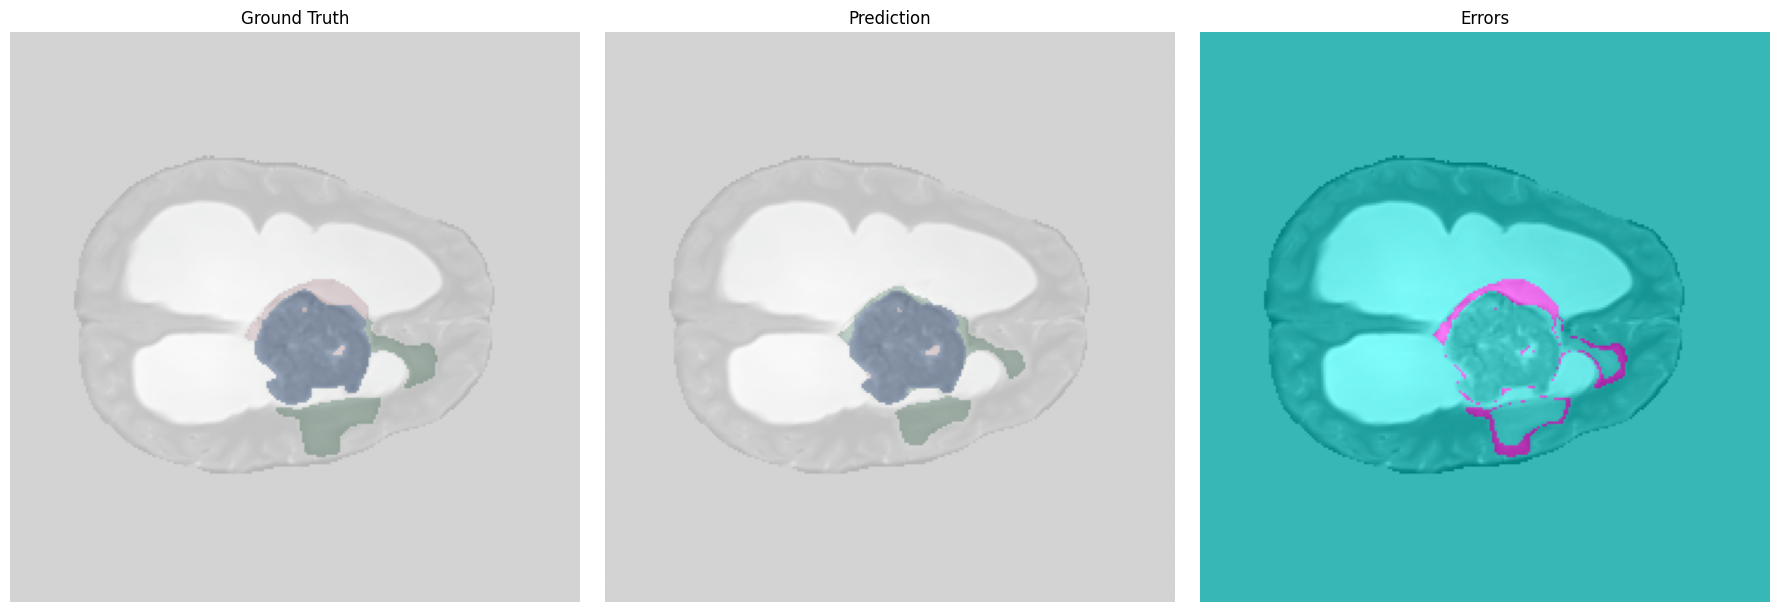

In [39]:
state_dict = torch.load("/kaggle/input/models/evgeniynn/residualunet/pytorch/default/4/best_model (3).pth",
    map_location=device
)

model.load_state_dict(state_dict)
model.to(device)

visualize_case_overlay_color(model, val_dataset, idx=20, slice_id=100, context=10, device=device)

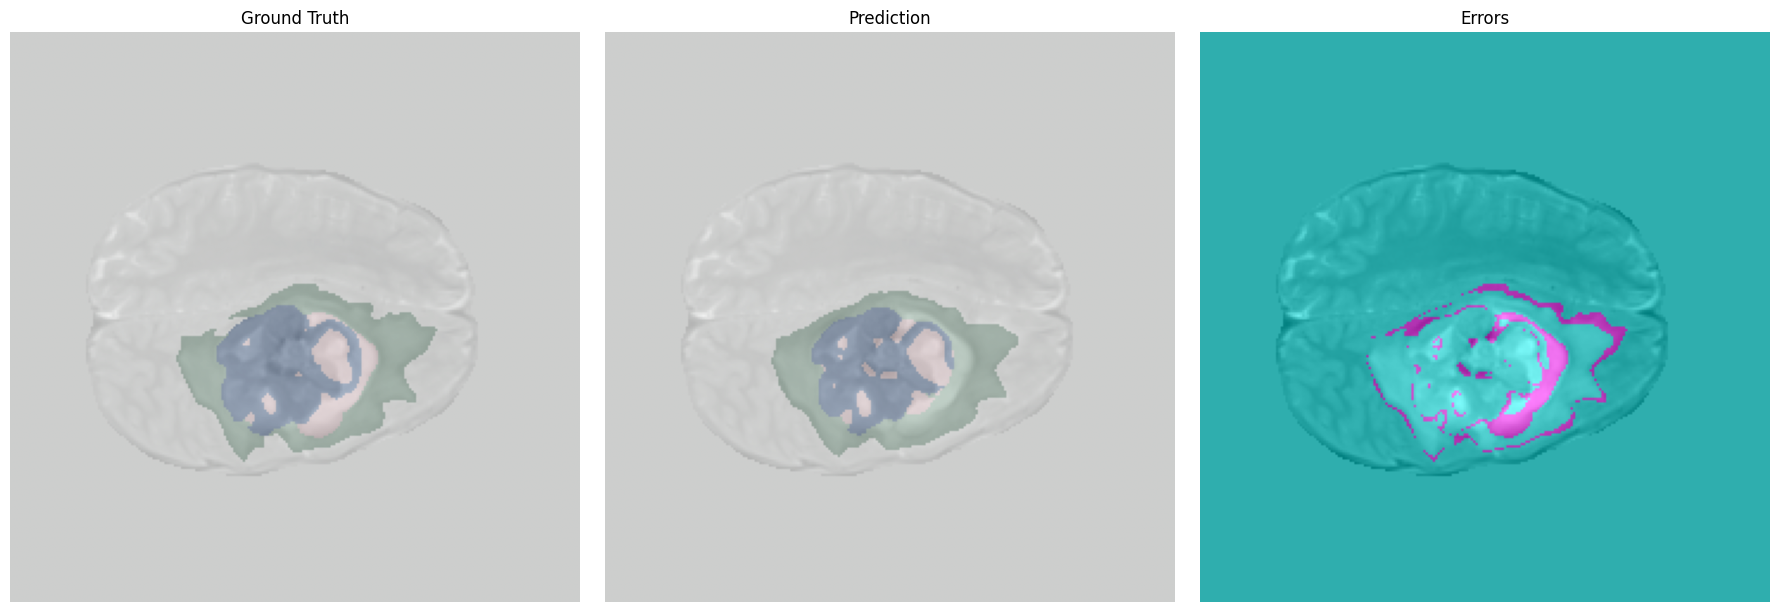

In [40]:
visualize_case_overlay_color(model, val_dataset, idx=7, slice_id=100, context=10, device=device)

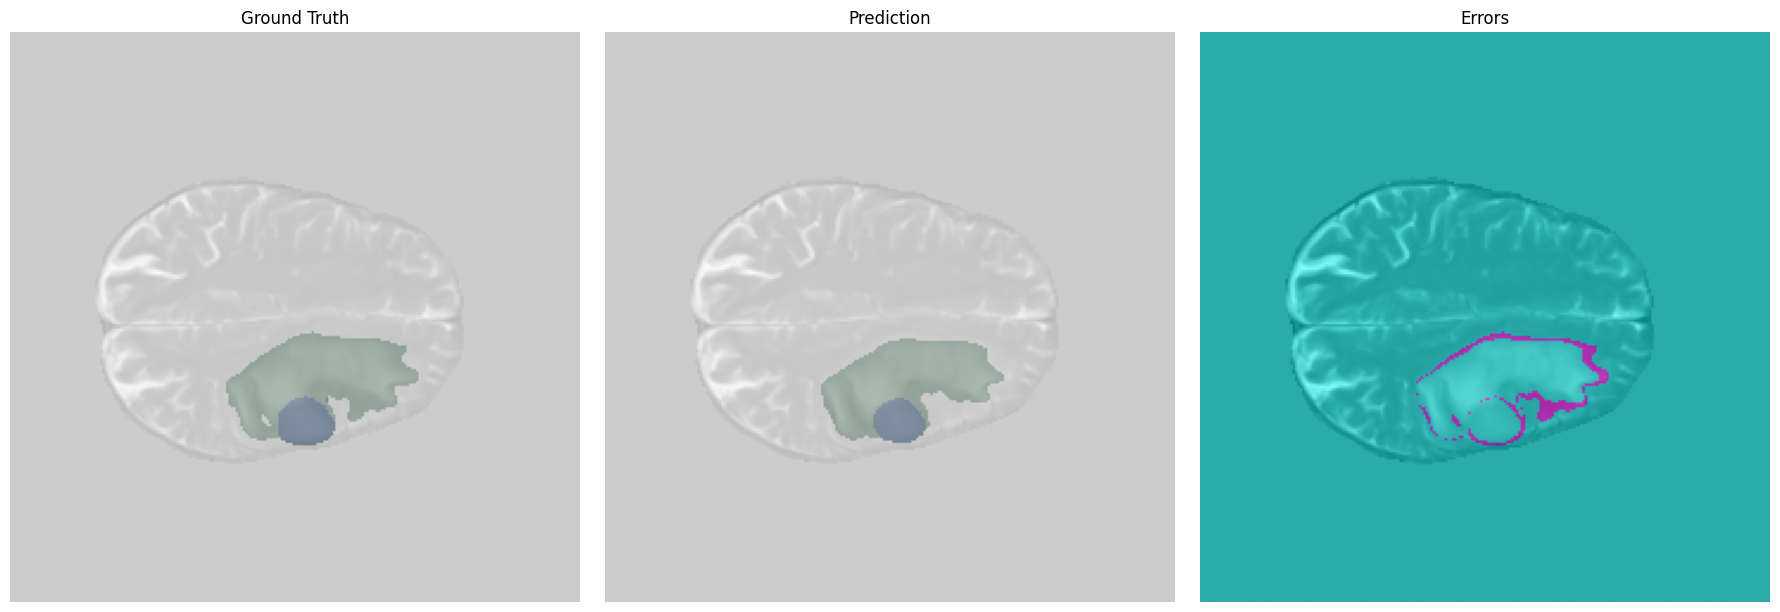

In [41]:
visualize_case_overlay_color(model, val_dataset, idx=3, slice_id=100, context=10, device=device)

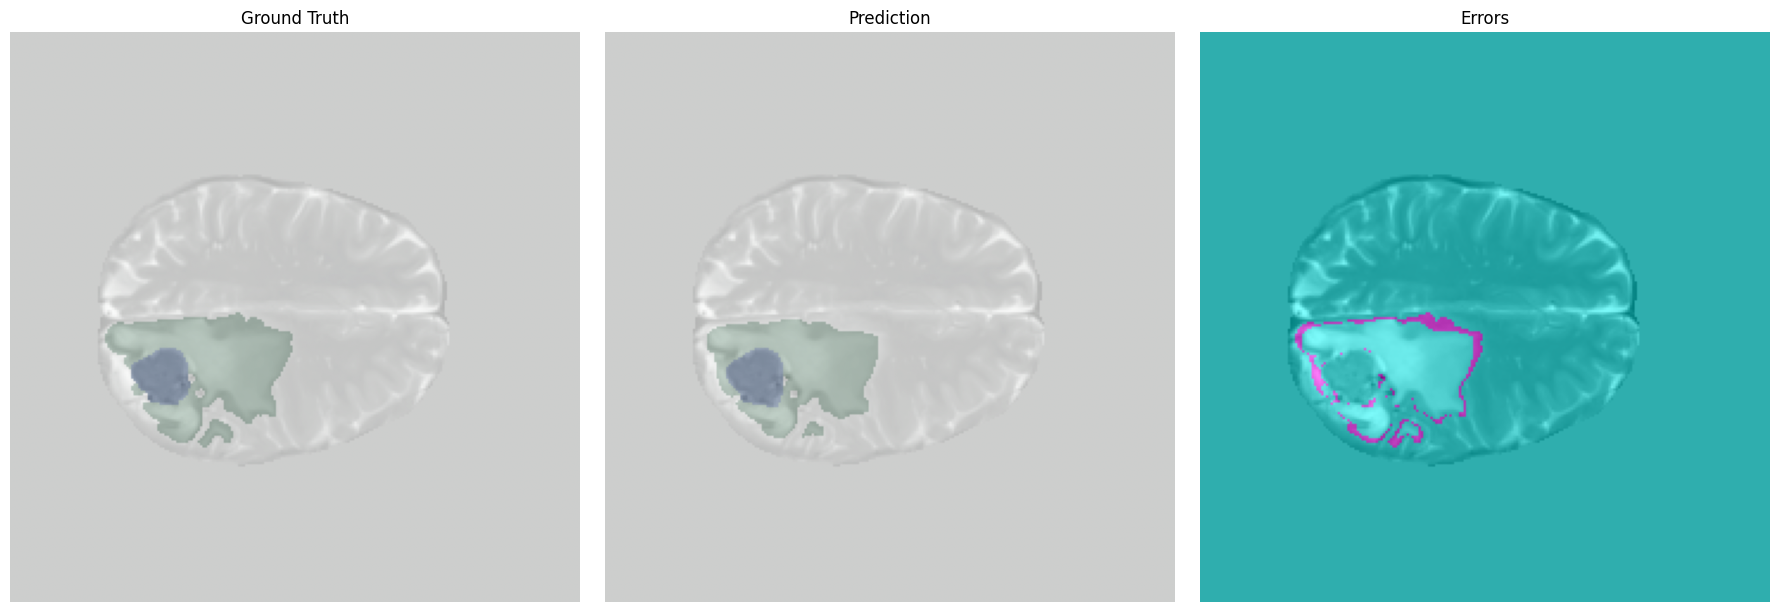

In [42]:
visualize_case_overlay_color(model, val_dataset, idx=12, slice_id=100, context=10, device=device)